In [1]:
import sys
from pathlib import Path
import pandas as pd
import config
import preprocessing as pre
from model import SentimentScorer
from utils import get_trend, plot_trend_df

D:\Jupyter\hf\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
input_data_path = Path(config.input_csv_path)
output_path = Path(config.output_csv_path)
plot_output = Path(config.output_plot_path)

In [3]:
if not input_data_path.is_file():
    print("csv not found")
    sys.exit(1)

cols_req = ["content_snippet", "published", "indexed"]

raw_data = pd.read_csv(input_data_path, usecols=cols_req)  # could use low_memory = True

raw_data['clean_data'] = raw_data['content_snippet'].map(
    lambda x: pre.clean_tweet(x, config.MAX_CHARS))
raw_data.head()

,indexed,published,content_snippet,clean_data
0,01/01/24 11:00:32,01/01/2024,Takım: Galatasaray Transfer oyuncu: Nicolò Zan...,Takım: Galatasaray Transfer oyuncu: Nicolò Zan...
1,01/01/24 20:55:38,01/01/2024,Nicolo Zaniolo X Big Boy 🔥 pic.twitter.com/cYv...,Nicolo Zaniolo X Big Boy
2,01/01/24 11:30:15,01/01/2024,Premier League goals for Aston Villa in 2023 👀...,Premier League goals for Aston Villa in 2023 ...
3,01/01/24 22:40:43,01/01/2024,yönetim ve teknik ekibe mail atmak yerine ista...,yönetim ve teknik ekibe mail atmak yerine ista...
4,01/01/24 14:21:49,01/01/2024,"2023'de attığımız en güzel,en anlamlı GOL bu G...","2023'de attığımız en güzel,en anlamlı GOL bu G..."


In [5]:
df = raw_data.loc[raw_data["clean_data"].str.len() > 0].copy()
if df.empty:
    print("No non-empty content_snippet rows.")
    sys.exit(1)
df["date"] = pre.parse_datetimes(df)
df.dropna(subset=["date"], inplace=True)

texts = df["clean_data"].tolist()
texts[:3]

['Takım: Galatasaray Transfer oyuncu: Nicolò Zaniolo',
 'Nicolo Zaniolo X Big Boy ',
 'Premier League goals for Aston Villa in 2023  21 - Ollie Watkins 11 - Douglas Luiz 7 - Leon Bailey 6 - John McGinn 5 - Jacob Ramsey 4 - Emiliano Buendia, Moussa Diaby 2 - Bertrand Traore, Pau Torres, Jhon Duran, Matty Cash 1 - Tyrone Mings, Leander Dendoncker, Nicolo Zaniolo,']

In [6]:
print(f"Starting scoring of tweets using: {config.MODEL_ID}")
try:
    scorer = SentimentScorer(
        model_id=config.MODEL_ID,
        batch_size=config.BATCH_SIZE,
        device=config.DEVICE
    )
    scores_rows = scorer.predict(texts)
except Exception as e:
    print(f"Inference failed: {e}")

df["sentiment_score"] = [r[0] for r in scores_rows]
df["pred_label"] = [r[1] for r in scores_rows]
df["prob_positive"] = [r[2] for r in scores_rows]
df["prob_neutral"] = [r[3] for r in scores_rows]
df["prob_negative"] = [r[4] for r in scores_rows]

overall = {
    "tweets analyzed": len(df),
    "share_of_positive_sentiment": (df["pred_label"] == "positive").mean(),
    "share_of_neutral_sentiment": (df["pred_label"] == "neutral").mean(),
    "share_of_negative_sentiment": (df["pred_label"] == "negative").mean(),
}
print("\n=== Overall Stats ===")
for k, v in overall.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.2f}")
    else:
        print(f"  {k}: {v}")

Starting scoring of tweets using: cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual


Loading weights: 100%|████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 17305.86it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Sentiment analysis:   3%|█▊                                                   | 320/9385 [00:02<00:50, 179.33snippet/s]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Sentiment analysis: 9408snippet [01:17, 121.28snippet/s]                                                               


=== Overall Stats ===
  tweets analyzed: 9385
  share_of_positive_sentiment: 0.23
  share_of_neutral_sentiment: 0.58
  share_of_negative_sentiment: 0.20


In [7]:
if output_path is not None:
    out_df = df[
        [
            "date",
            "clean_data",
            "sentiment_score",
            "pred_label",
            "prob_positive",
            "prob_neutral",
            "prob_negative",
        ]
    ].copy()
output_path.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(output_path, index=False)

print(f"Wrote results to {output_path}")

Wrote results to output\sentiment_scores.csv


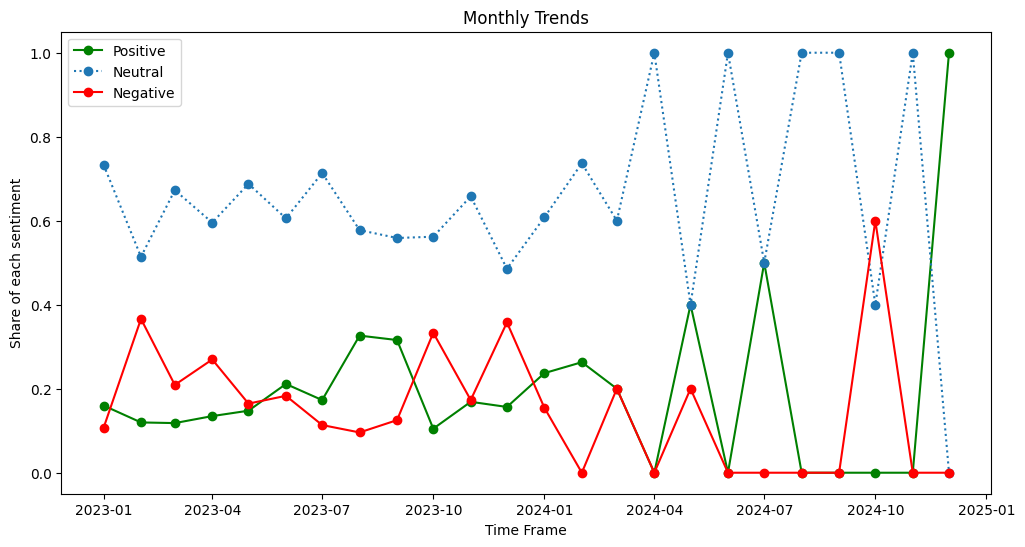

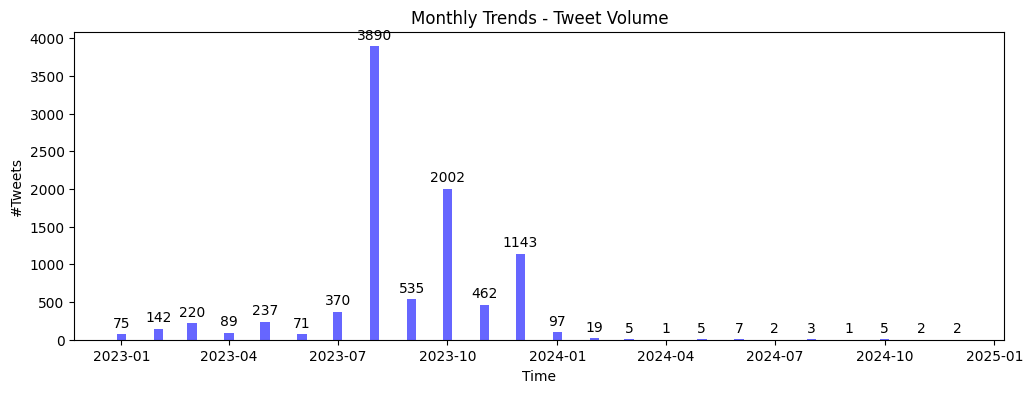

In [6]:
df_trend = get_trend(df, "month")
plot_trend_df(df_trend, "Monthly Trends")
